In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

# Style
plt.style.use("dark_background")
sns.set_palette("husl")

# BigQuery client
PROJECT_ID = "my-data-project-488902"
client = bigquery.Client(project=PROJECT_ID)

print("✅ Setup complete")

✅ Setup complete


In [3]:
# Load prices
prices = client.query("""
    SELECT ticker, date, close
    FROM `my-data-project-488902.market_movers.prices_raw`
    ORDER BY ticker, date
""").to_dataframe()

# Load features
features = client.query("""
    SELECT *
    FROM `my-data-project-488902.market_movers.features`
    ORDER BY ticker, date
""").to_dataframe()

# Load predictions
predictions = client.query("""
    SELECT *
    FROM `my-data-project-488902.market_movers.predictions`
    ORDER BY date
""").to_dataframe()

print(f"✅ Prices: {len(prices)} rows")
print(f"✅ Features: {len(features)} rows")
print(f"✅ Predictions: {len(predictions)} rows")

c:\Users\kiaja\GitHub\data-quality-and-analytics-portfolio\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✅ Prices: 6280 rows
✅ Features: 5008 rows
✅ Predictions: 1002 rows


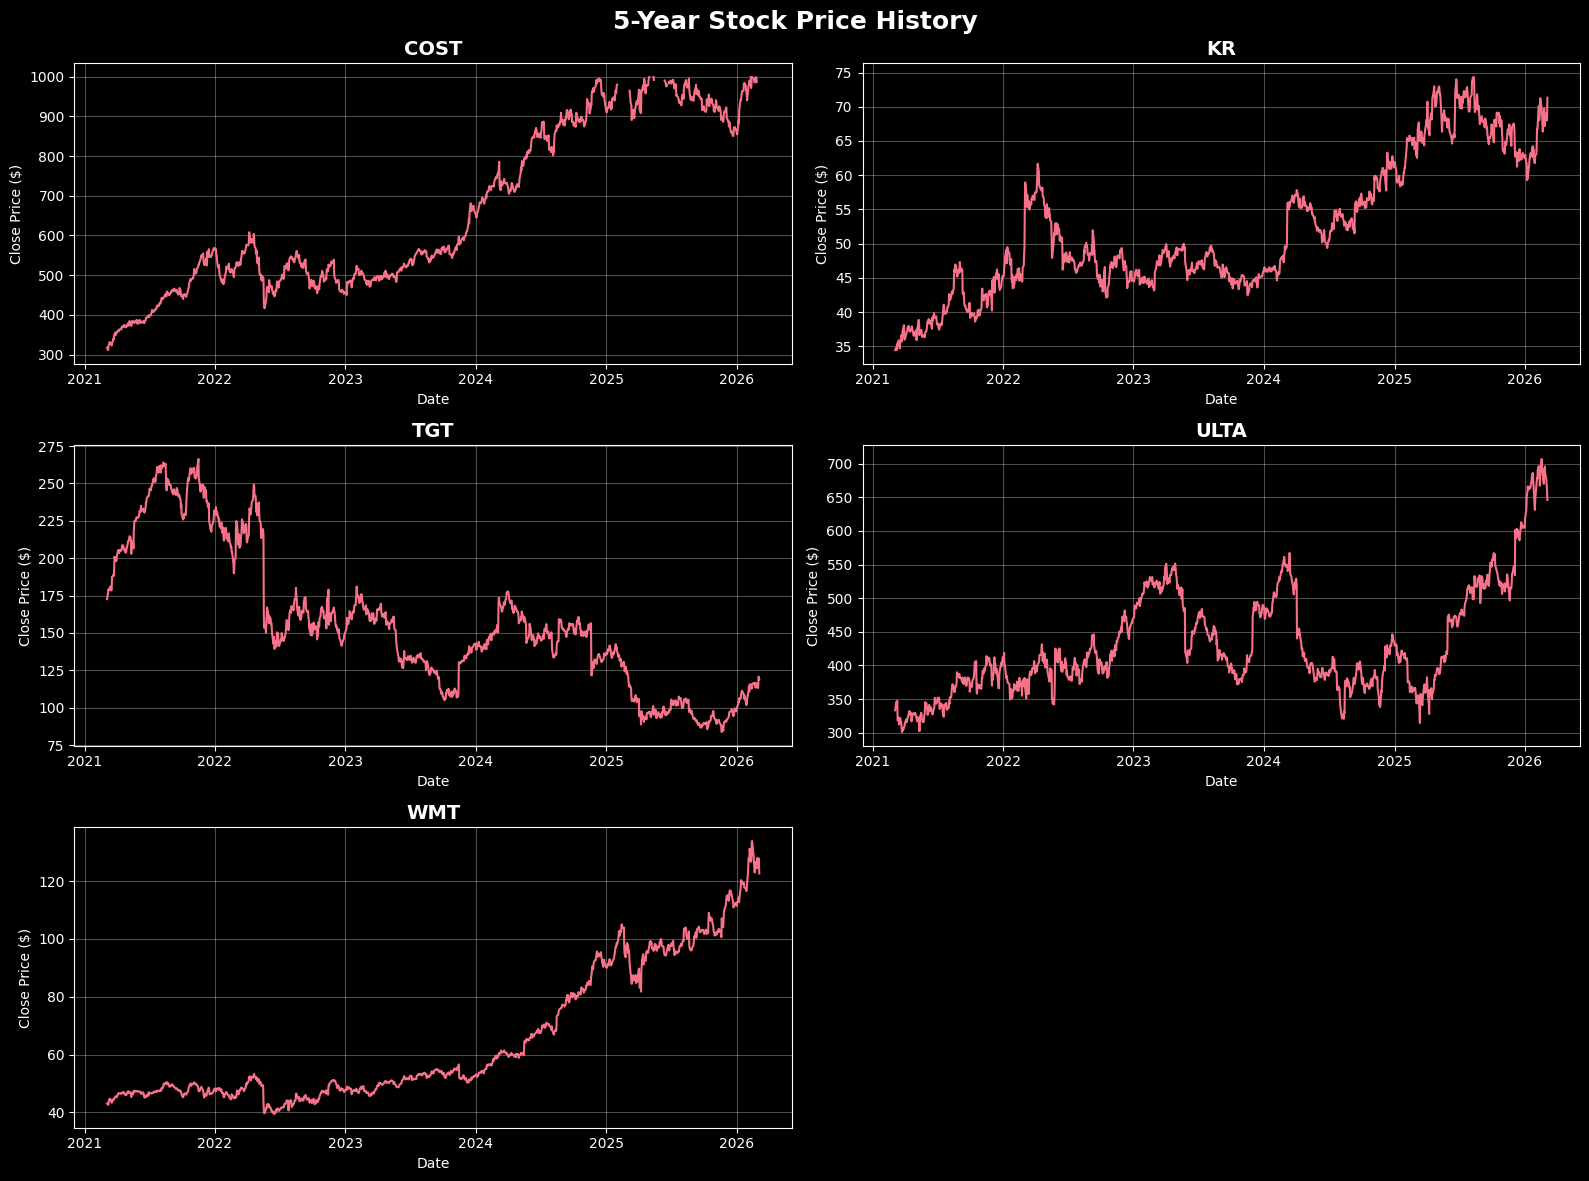

✅ Chart saved


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("5-Year Stock Price History", fontsize=18, fontweight="bold")

tickers = prices["ticker"].unique()
axes_flat = axes.flatten()

for i, ticker in enumerate(tickers):
    df = prices[prices["ticker"] == ticker]
    axes_flat[i].plot(df["date"], df["close"], linewidth=1.5)
    axes_flat[i].set_title(ticker, fontsize=14, fontweight="bold")
    axes_flat[i].set_xlabel("Date")
    axes_flat[i].set_ylabel("Close Price ($)")
    axes_flat[i].grid(alpha=0.3)

# Hide the 6th empty subplot
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig("../images/01_price_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

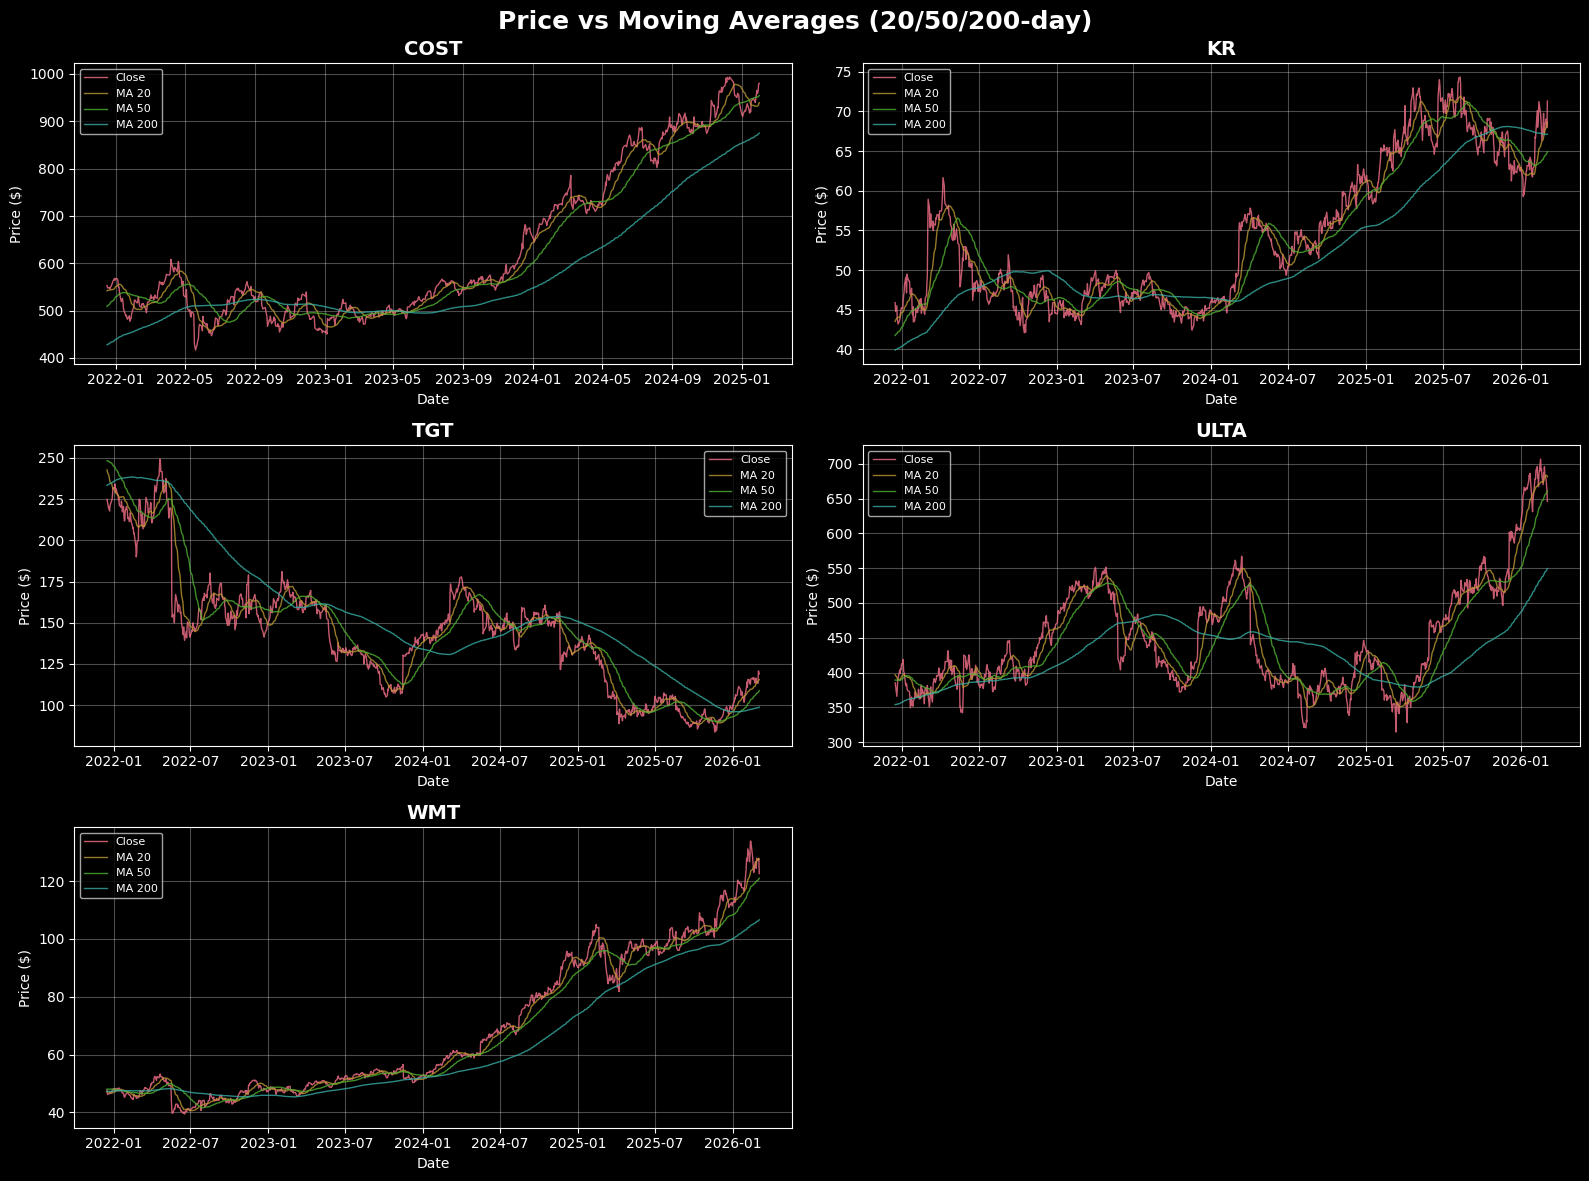

✅ Chart saved


In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Price vs Moving Averages (20/50/200-day)", fontsize=18, fontweight="bold")

axes_flat = axes.flatten()

for i, ticker in enumerate(tickers):
    df = features[features["ticker"] == ticker].sort_values("date")
    ax = axes_flat[i]
    ax.plot(df["date"], df["close"], linewidth=1, label="Close", alpha=0.8)
    ax.plot(df["date"], df["ma_20"], linewidth=1, label="MA 20", alpha=0.8)
    ax.plot(df["date"], df["ma_50"], linewidth=1, label="MA 50", alpha=0.8)
    ax.plot(df["date"], df["ma_200"], linewidth=1, label="MA 200", alpha=0.8)
    ax.set_title(ticker, fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price ($)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig("../images/02_moving_averages.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

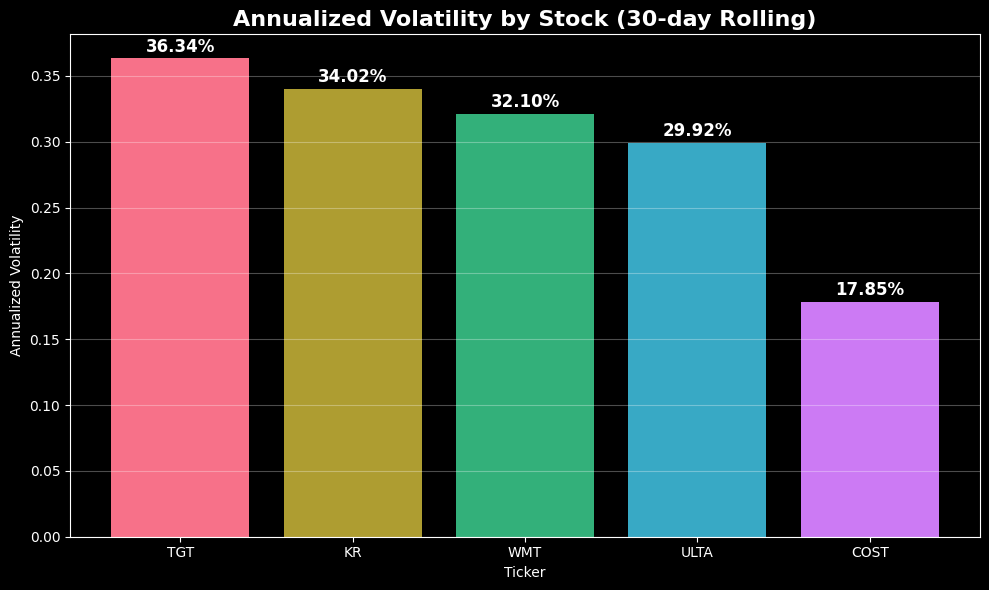

✅ Chart saved


In [6]:
# Get the most recent 30-day volatility for each ticker
latest_vol = features.groupby("ticker")["volatility_30"].last().reset_index()
latest_vol = latest_vol.sort_values("volatility_30", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(latest_vol["ticker"], latest_vol["volatility_30"], color=sns.color_palette("husl", 5))
ax.set_title("Annualized Volatility by Stock (30-day Rolling)", fontsize=16, fontweight="bold")
ax.set_xlabel("Ticker")
ax.set_ylabel("Annualized Volatility")
ax.grid(alpha=0.3, axis="y")

# Add value labels on bars
for bar, val in zip(bars, latest_vol["volatility_30"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.2%}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/03_volatility.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

c:\Users\kiaja\GitHub\data-quality-and-analytics-portfolio\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


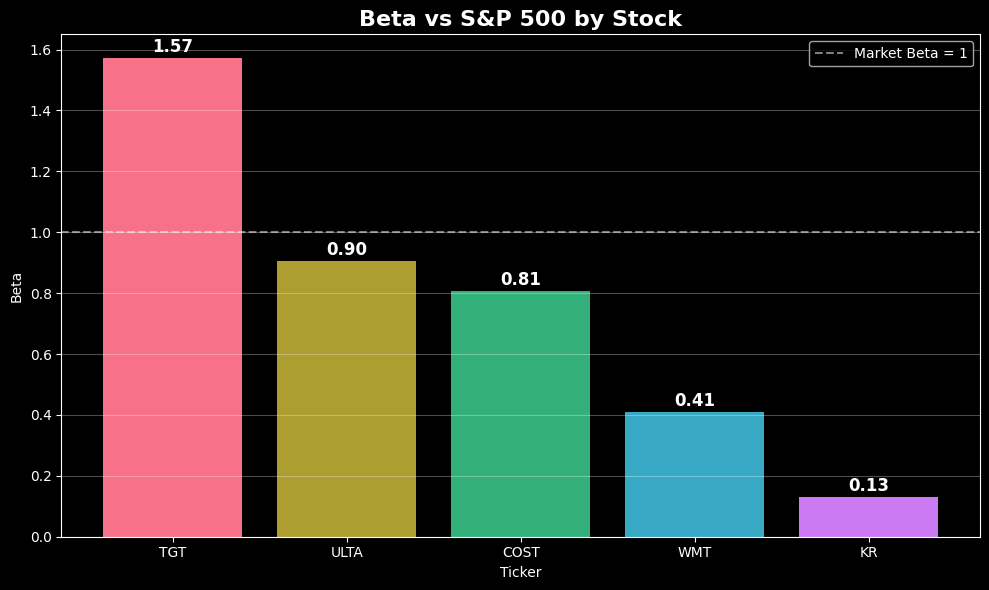

✅ Chart saved


In [7]:
# Load beta data
beta = client.query("""
    WITH returns AS (
        SELECT
            p.ticker,
            p.date,
            LN(p.close / LAG(p.close) OVER (
                PARTITION BY p.ticker ORDER BY p.date
            )) AS stock_return,
            LN(s.close / LAG(s.close) OVER (
                ORDER BY s.date
            )) AS market_return
        FROM `my-data-project-488902.market_movers.prices_raw` p
        JOIN `my-data-project-488902.market_movers.index_prices` s
        ON p.date = s.date
    )
    SELECT
        ticker,
        ROUND(COVAR_SAMP(stock_return, market_return) / VAR_SAMP(market_return), 4) AS beta
    FROM returns
    WHERE stock_return IS NOT NULL AND market_return IS NOT NULL
    GROUP BY ticker
    ORDER BY beta DESC
""").to_dataframe()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(beta["ticker"], beta["beta"], color=sns.color_palette("husl", 5))
ax.axhline(y=1, color="white", linestyle="--", alpha=0.5, label="Market Beta = 1")
ax.set_title("Beta vs S&P 500 by Stock", fontsize=16, fontweight="bold")
ax.set_xlabel("Ticker")
ax.set_ylabel("Beta")
ax.legend()
ax.grid(alpha=0.3, axis="y")

for bar, val in zip(bars, beta["beta"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/04_beta.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

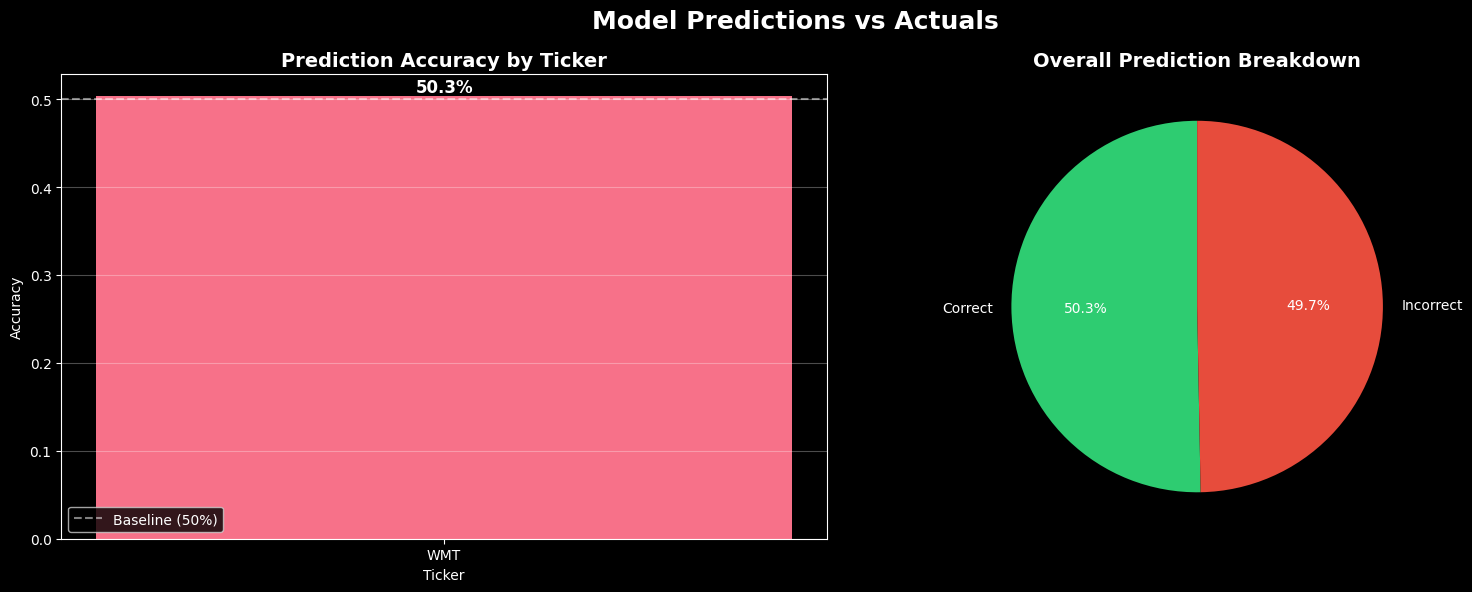

✅ Chart saved


In [8]:
# Count correct and incorrect predictions
predictions["correct"] = (predictions["actual"] == predictions["predicted"]).astype(int)

# Accuracy by ticker
accuracy_by_ticker = predictions.groupby("ticker")["correct"].mean().reset_index()
accuracy_by_ticker.columns = ["ticker", "accuracy"]
accuracy_by_ticker = accuracy_by_ticker.sort_values("accuracy", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Predictions vs Actuals", fontsize=18, fontweight="bold")

# Left chart - accuracy by ticker
bars = axes[0].bar(accuracy_by_ticker["ticker"], accuracy_by_ticker["accuracy"],
                   color=sns.color_palette("husl", 5))
axes[0].axhline(y=0.5, color="white", linestyle="--", alpha=0.5, label="Baseline (50%)")
axes[0].set_title("Prediction Accuracy by Ticker", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Ticker")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

for bar, val in zip(bars, accuracy_by_ticker["accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.1%}", ha="center", fontsize=12, fontweight="bold")

# Right chart - overall confusion breakdown
correct_count = predictions["correct"].sum()
incorrect_count = len(predictions) - correct_count
axes[1].pie([correct_count, incorrect_count],
            labels=["Correct", "Incorrect"],
            autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"],
            startangle=90)
axes[1].set_title("Overall Prediction Breakdown", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/05_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

In [9]:
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)

print(f"\n📊 Dataset:")
print(f"   Tickers: {sorted(prices['ticker'].unique().tolist())}")
print(f"   Total trading days: {len(prices)}")
print(f"   Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")

print(f"\n📈 Volatility (most recent):")
for _, row in latest_vol.iterrows():
    print(f"   {row['ticker']}: {row['volatility_30']:.2%}")

print(f"\n📉 Beta vs S&P 500:")
for _, row in beta.iterrows():
    print(f"   {row['ticker']}: {row['beta']:.4f}")

print(f"\n🤖 Model Performance:")
print(f"   Training rows: 4006")
print(f"   Test rows: 1002")
print(f"   Overall accuracy: {predictions['correct'].mean():.2%}")
print(f"\n   Accuracy by ticker:")
for _, row in accuracy_by_ticker.iterrows():
    print(f"   {row['ticker']}: {row['accuracy']:.2%}")

print("\n" + "=" * 50)

PROJECT SUMMARY

📊 Dataset:
   Tickers: ['COST', 'KR', 'TGT', 'ULTA', 'WMT']
   Total trading days: 6280
   Date range: 2021-03-05 to 2026-03-05

📈 Volatility (most recent):
   TGT: 36.34%
   KR: 34.02%
   WMT: 32.10%
   ULTA: 29.92%
   COST: 17.85%

📉 Beta vs S&P 500:
   TGT: 1.5714
   ULTA: 0.9044
   COST: 0.8061
   WMT: 0.4097
   KR: 0.1297

🤖 Model Performance:
   Training rows: 4006
   Test rows: 1002
   Overall accuracy: 50.30%

   Accuracy by ticker:
   WMT: 50.30%

